# Segmentation

### What is Segmentation
Think of Semantic Segmentation as "Deep Learning at the pixel level."

In standard image classification, the model looks at a photo and says, "There is a cat in this image." In semantic segmentation, the model must decide for every single pixel in the image: "Does this pixel belong to a cat, a tree, or the sky?"

## What is U-Net Model?
U-Net is a convolutional neural network that was developed for image segmentation.The network is based on a fully convolutional neural network whose architecture was modified and extended to work with fewer training images and to yield more precise segmentation. Segmentation of a 512 x 512 image takes less than a second on a modern (2015) GPU using the U-Net architecture.
Reference: https://en.wikipedia.org/wiki/U-Net

Reference to the paper: Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "U-net: Convolutional networks for biomedical image segmentation." In International Conference on Medical image computing and computer-assisted intervention, pp. 234-241. Cham: Springer international publishing, 2015.

The paper is available here https://arxiv.org/abs/1505.04597

## Layers in a U-Net Model
Think of the U-Net as a "U-shaped" bridge. Its goal is to take an image, understand the "big picture," and then reconstruct it pixel-by-pixel to create a precise map. It is divided into two halves:
1. The Encoder (The Downward Path)

This is the "Contracting" side. It works like a standard image classifier. It uses blocks of Convolution and Pooling layers to shrink the image's dimensions while increasing the number of features. It's goal is to to understand **"What"** is in the image (e.g., "There is a cat here"), even if it loses track of exactly where the edges are.

2. The Decoder (The Upward Path)

This is the "Extensive" side. It does the reverse of the Encoder. It uses "Up-convolutions" to expand the image back to its original size. It's goal is to figure out **"Where"** the object is located with pixel-perfect precision.

3. Skip Connections

This is what makes U-Net special. Since the Encoder loses spatial detail during shrinking, U-Net "copies" the high-resolution features from the Encoder and "pastes" them directly into the Decoder. It helps the model recover fine details (like whiskers or sharp edges) that would otherwise be blurred.


<img src="https://raw.githubusercontent.com/hazratali/deep-learning-course/main/assets/img/unet.png" alt="the unet architecture" width=1000/>
The U-Net Architecture. Source: https://arxiv.org/abs/1505.04597


# Importing the libraries
First, import the necessary libraries.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image


Using device: cuda


# Setting up device-agnostic code.


In [ ]:
# TO DO
write code here to setup device-agnostic code and use GPU when available.

## Implementing the UNet architecture

1. **The Downward Path (Encoder)**

This part is the "Contracting" side of the "U."


`nn.MaxPool2d`: This is the "shrinking" command. With kernel_size=2 and stride=2, it takes a 2×2 block of pixels and keeps only the largest value. This reduces the image size by half (e.g., 128×128 --> 64×64).


`nn.ModuleList()`: We can't just use a standard Python list to store layers, because PyTorch won't see them to update their weights. ModuleList tells PyTorch, "Hey, track the parameters inside these items!"

2. **The Bridge: self.bottleneck**

This is the very bottom of the "U." By this point, the image is at its smallest spatial size but has the highest number of "features" (channels). It’s the densest representation of what the model has seen.

3. **The Upward Path (Decoder)**

This is the "Expansive" side where we reconstruct the image.
nn.ConvTranspose2d: Unlike MaxPool which throws away data, this is a learned upsampling. It uses weights to "guess" how to stretch a 1×1 pixel back into a 2×2 block.
The code uses range(0, len(self.ups), 2) because the ups list contains pairs: an up-sampler and a DoubleConv.

4. **The Skip Connections**
This is where the U-Net outperforms standard networks.

`torch.cat((skip_connection, x), dim=1)`: This is an important line. It takes the high-resolution features from the Downward path and attaches them to the Upward path.

`transforms.functional.resize`: Real-world images aren't always perfect powers of 2. If your input is 125×125, the pooling might result in a size mismatch during the skip connectinos phase. This line ensures the shapes match perfectly before they are concatenated.

In [ ]:
class DoubleConv(nn.Module):
    """(Convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Down part of U-Net
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Up part of U-Net
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip_connection = skip_connections[i//2]

            # If input size is not divisible by 2^n, padding might be needed
            if x.shape != skip_connection.shape:
                x = transforms.functional.resize(x, size=skip_connection.shape[2:])

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[i+1](concat_skip)

        return self.final_conv(x)

Perform a quick test on the model.
Instantiate it by `model = UNet(in_channels=3, out_channels=1).to(device)`

Then, create a random tensor `x` of size [1, 3, 160, 160] using `torch.random` and move it to device. For such an input, your expected output shape will be [1, 1, 160, 160]

In [ ]:
# Quick Test
# TO DO
# write code here

print(f"Output shape: {model(x).shape}") # Should be [1, 1, 160, 160]

Output shape: torch.Size([1, 1, 160, 160])


## Model summary
Use torchinfo to get an idea of the shapes going through our model

A helpful way to get information from our model is to use torchinfo.

torchinfo comes with a `summary()` method that takes a PyTorch model as well as an input_shape and returns what happens as a tensor moves through your model.

Note: If you're using Google Colab, you'll need to install torchinfo.

Write code below to print the summary of the model for an input_size of `[1, 3, 64, 64]`


In [ ]:
# Install torchinfo if it's not available, import it if it is
# TO DO
write code here


Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 1, 64, 64]            --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-1                   [1, 64, 64, 64]           --
│    │    └─Sequential: 3-1              [1, 64, 64, 64]           38,848
├─MaxPool2d: 1-2                         [1, 64, 32, 32]           --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-2                   [1, 128, 32, 32]          --
│    │    └─Sequential: 3-2              [1, 128, 32, 32]          221,696
├─MaxPool2d: 1-4                         [1, 128, 16, 16]          --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-3                   [1, 256, 16, 16]          --
│    │    └─Sequential: 3-3              [1, 256, 16, 16]          885,760
├─MaxPool2d: 1-6                         [1,

Your expected output for the above cell will be similar to:
```
==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
==========================================================================================
UNet                                     [1, 1, 64, 64]            --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-1                   [1, 64, 64, 64]           --
│    │    └─Sequential: 3-1              [1, 64, 64, 64]           38,848
├─MaxPool2d: 1-2                         [1, 64, 32, 32]           --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-2                   [1, 128, 32, 32]          --
│    │    └─Sequential: 3-2              [1, 128, 32, 32]          221,696
├─MaxPool2d: 1-4                         [1, 128, 16, 16]          --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-3                   [1, 256, 16, 16]          --
│    │    └─Sequential: 3-3              [1, 256, 16, 16]          885,760
├─MaxPool2d: 1-6                         [1, 256, 8, 8]            --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-4                   [1, 512, 8, 8]            --
│    │    └─Sequential: 3-4              [1, 512, 8, 8]            3,540,992
├─MaxPool2d: 1-8                         [1, 512, 4, 4]            --
├─DoubleConv: 1-9                        [1, 1024, 4, 4]           --
│    └─Sequential: 2-5                   [1, 1024, 4, 4]           --
│    │    └─Conv2d: 3-5                  [1, 1024, 4, 4]           4,718,592
│    │    └─BatchNorm2d: 3-6             [1, 1024, 4, 4]           2,048
│    │    └─ReLU: 3-7                    [1, 1024, 4, 4]           --
│    │    └─Conv2d: 3-8                  [1, 1024, 4, 4]           9,437,184
│    │    └─BatchNorm2d: 3-9             [1, 1024, 4, 4]           2,048
│    │    └─ReLU: 3-10                   [1, 1024, 4, 4]           --
├─ModuleList: 1-10                       --                        --
│    └─ConvTranspose2d: 2-6              [1, 512, 8, 8]            2,097,664
│    └─DoubleConv: 2-7                   [1, 512, 8, 8]            --
│    │    └─Sequential: 3-11             [1, 512, 8, 8]            7,079,936
│    └─ConvTranspose2d: 2-8              [1, 256, 16, 16]          524,544
│    └─DoubleConv: 2-9                   [1, 256, 16, 16]          --
│    │    └─Sequential: 3-12             [1, 256, 16, 16]          1,770,496
│    └─ConvTranspose2d: 2-10             [1, 128, 32, 32]          131,200
│    └─DoubleConv: 2-11                  [1, 128, 32, 32]          --
│    │    └─Sequential: 3-13             [1, 128, 32, 32]          442,880
│    └─ConvTranspose2d: 2-12             [1, 64, 64, 64]           32,832
│    └─DoubleConv: 2-13                  [1, 64, 64, 64]           --
│    │    └─Sequential: 3-14             [1, 64, 64, 64]           110,848
├─Conv2d: 1-11                           [1, 1, 64, 64]            65
==========================================================================================
Total params: 31,037,633
Trainable params: 31,037,633
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 3.41
==========================================================================================
Input size (MB): 0.05
Forward/backward pass size (MB): 35.95
Params size (MB): 124.15
Estimated Total Size (MB): 160.15
```

# Defining the transforms on the data
Let us define the transforms that we will apply to the images and the masks when we download the data.

In [ ]:
def transform_mask(mask):
    # Convert mask to binary (1 for pet, 0 for background/border)
    mask = np.array(mask)
    mask[mask != 1] = 0 # In this dataset, 1 is the foreground (pet)
    return torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

# Transformations
image_transforms = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mask_transforms = transforms.Compose([
    transforms.Resize((160, 160), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.Lambda(transform_mask)
])

### Downloading the Oxford-IIITPet datasets
The Oxford IIITPet dataset is a 37 category pet dataset with roughly 200 images for each class.
It is a collection of images used for fine-grained classification of pets, specifically featuring 37 different breeds of dogs and cats, with around 200 images for each breed.

The images have a large variations in scale, pose and lighting.

Is it useful for Segmentation tasks?
Yes, the dataset includes images of pets along with ground truth masks that indicate the segmentation of different classes, such as background, border, and pet. These masks help in training models for tasks like **semantic segmentation** in computer vision.

You can read more about this dataset at https://www.robots.ox.ac.uk/~vgg/data/pets/

In [ ]:
# Loading Dataset
train_dataset = datasets.OxfordIIITPet(root='./data', target_types='segmentation', download=True,
                                       transform=image_transforms, target_transform=mask_transforms)


100%|██████████| 792M/792M [00:36<00:00, 21.6MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.7MB/s]


Look at the data you just downloaded.

It has two key folders, the images folder and the annotations folder.

**1. The Image Folder: It contains 7,000 JPEG images.**

- Naming Convention: Species_Number.jpg (e.g., Abyssinian_1.jpg or yorkshire_terrier_150.jpg).

- The naming convention itself tells you the breed. If the first letter is uppercase, it’s a cat; if it’s lowercase, it’s a dog.

**2. The annotations folder: It contains the labels and the masks.**
- `trimaps/`: I contains .png files that match the image names. These are the pixel-level masks used for segmentation (identifying the pet, the background, and the outline).

- `xmls/`: It contains bounding box data in PASCAL VOC format (you may not need this for segmentation tasks).

- `list.txt, trainval.txt, test.txt`: Text files that tell PyTorch which images belong to which split and which breed ID.

We can quickly print the directory structure using `os.walk`.

Write code below to print the directory structure.

Hint: You can use the `walk_through_dir` function from one of the prevous practicals. An expected output is shown after the cell.

In [ ]:
# TO DO
# write code here

walk_through_dir(data_path)

There are 2 directories and 2 files in 'data/oxford-iiit-pet'.
There are 2 directories and 5 files in 'data/oxford-iiit-pet/annotations'.
There are 0 directories and 14780 files in 'data/oxford-iiit-pet/annotations/trimaps'.
There are 0 directories and 3686 files in 'data/oxford-iiit-pet/annotations/xmls'.
There are 0 directories and 7393 files in 'data/oxford-iiit-pet/images'.


Your expected directory structure will be something like:

```
There are 2 directories and 2 files in 'data/oxford-iiit-pet'.
There are 2 directories and 5 files in 'data/oxford-iiit-pet/annotations'.
There are 0 directories and 14780 files in 'data/oxford-iiit-pet/annotations/trimaps'.
There are 0 directories and 3686 files in 'data/oxford-iiit-pet/annotations/xmls'.
There are 0 directories and 7393 files in 'data/oxford-iiit-pet/images'.
```

# Visualizing the data

Next, we want to visualize some of the images along with the masks.
If we enumerate over some random indices, we can pick an images along with the corresponding masks by using, for example,
```
for idx, i in enumerate(indices):
    img, mask = dataset[i]
```

Let us write a function named `visualize_pet_data`. the input to the fuction is the data and, the input, and a number of samples to be plotted.

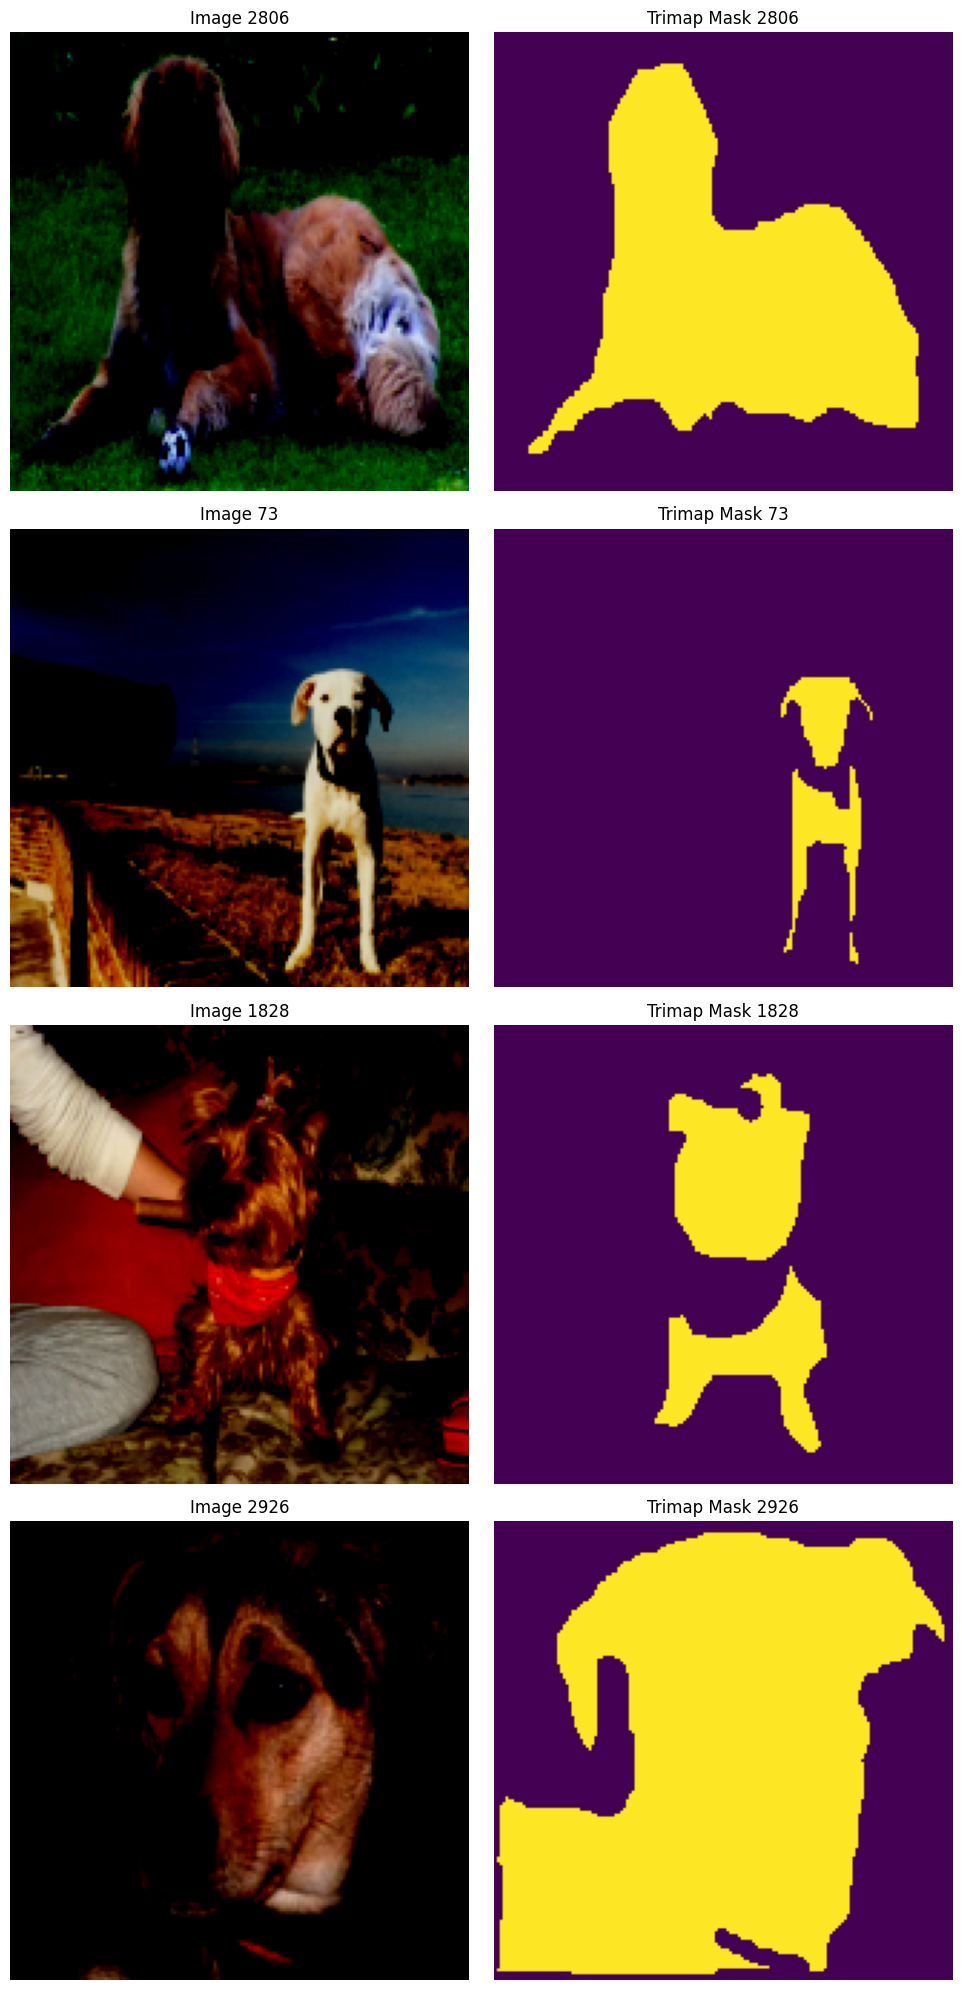

In [ ]:
def visualize_pet_data(dataset, num_samples=4):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 5))

    # 2. Pick random indices
    indices = random.sample(range(len(dataset)), num_samples)

    for idx, i in enumerate(indices):
        img, mask = dataset[i]

        # Convert PIL to Array for plotting
        img_arr = img.permute(1, 2, 0).cpu().numpy() #img_arr = np.array(img)
        mask_arr = mask.squeeze().cpu().numpy() # mask_arr = np.array(mask)

        # 3. Plotting the Image
        axes[idx, 0].imshow(img_arr)
        axes[idx, 0].set_title(f"Image {i}")
        axes[idx, 0].axis('off')

        # 4. Plotting the Mask
        # We use a specific colormap to see the 3 classes clearly
        axes[idx, 1].imshow(mask_arr, cmap = 'viridis') # use cmap='viridis' or cmap = 'gray')
        axes[idx, 1].set_title(f"Trimap Mask {i}")
        axes[idx, 1].axis('off')

    plt.tight_layout()
    plt.show()

visualize_pet_data(train_dataset)

## Load into the DataLoader
Next you want to load the data into the DataLoader

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [ ]:
len(train_loader)

230

### The loss function and the optimizer
Before defining our training function, let us define our training loss and optimizer. Here, we use the BCEWithLogitsLoss. And we use the Adam optimizer.

In [ ]:
# Why BCEWithLogitsLoss?
# It combines a Sigmoid layer and the BCELoss in one single class.
# This version is more numerically stable than using a plain Sigmoid followed by a BCELoss
# as, by combining the operations into one layer, it takes advantage of the log-sum-exp trick.
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Also, we define our dice_coefficient function. The dice_coefficient is:
$$Dice = \frac{2 \cdot |P \cap T| + \epsilon}{|P| + |T| + \epsilon}$$

- P: The set of predicted pixels (after applying the 0.5 threshold).

- T: The set of ground truth (target) pixels.

- ∣P∩T∣: The Intersection—the count of pixels where both the prediction and target are 1.

- ∣P∣+∣T∣: The sum of all "positive" pixels in both masks.

- $\epsilon$: A small constant (like $1x10^{−6}$) to ensure numerical stability.

In [ ]:
def dice_coeff(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred) > 0.5  # Binarize predictions
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

# Model training function

In [ ]:
# Import tqdm for progress bar
from tqdm.auto import tqdm
EPOCHS = 4
# Training Loop
def train(model, loader, optimizer, criterion):
    model.train()
    for epoch in tqdm(range(EPOCHS)):
      # total_loss = 0
      metrics = {'loss': 0, 'dice': 0, 'iou': 0}
      for images, masks in loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        metrics['loss'] += loss.item()
        metrics['dice'] += dice_coeff(outputs, masks).item()
      print(f"Epoch: {epoch} | Loss: {metrics['loss']/len(loader):.4f} | Dice: {metrics['dice']/len(loader):.4f}")

# Execute
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

train(model, train_loader, optimizer, criterion)

train_time_end_on_gpu = timer()
total_time = train_time_end_on_gpu - train_time_start_on_gpu
print(f"Train time on {device}: {total_time:.3f} seconds")

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 0 | Loss: 0.4219 | Dice: 0.7116
Epoch: 1 | Loss: 0.3018 | Dice: 0.8003
Epoch: 2 | Loss: 0.2541 | Dice: 0.8287
Epoch: 3 | Loss: 0.2258 | Dice: 0.8484
Train time on cuda: 365.361 seconds


I noticed that the training on a CPU took almost 9581 seconds for one epoch.

The training on a T4 GPU took almost 295 seconds for 3 epochs and around 404 seconds for 4 epochs.

You might expect training time in a similar range.

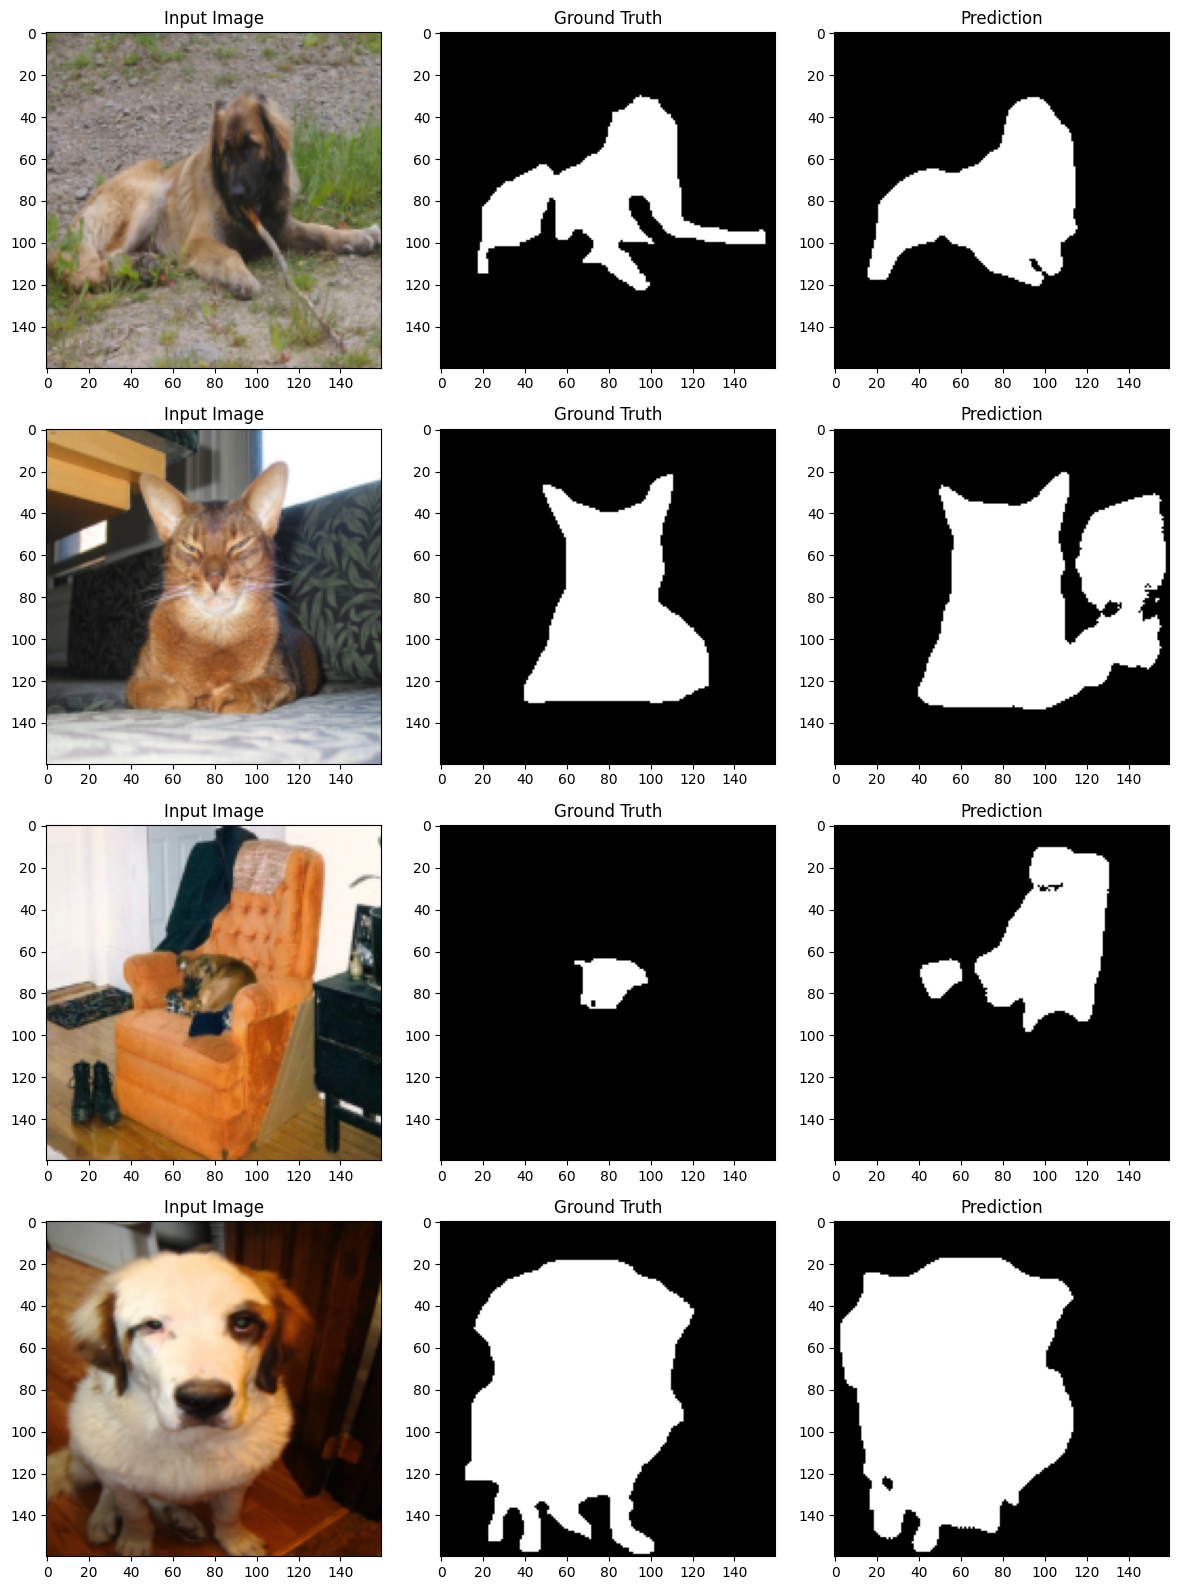

In [ ]:
import random
def visualize_results(model, dataset, num_samples=4):
    model.eval()

    total_images = len(dataset)
    random_indices = random.sample(range(total_images), num_samples) # Pick 'num_samples' unique random indices
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))

    # Iterate through the random selection
    for idx, i in enumerate(random_indices):

    # for i in range(num_samples):
        img, mask = dataset[i]
        img_input = img.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = torch.sigmoid(model(img_input))
            pred = (pred > 0.5).float().cpu().squeeze()

        axes[idx, 0].imshow(img.permute(1, 2, 0).numpy() * 0.5 + 0.5)
        axes[idx, 0].set_title("Input Image")
        axes[idx, 1].imshow(mask.squeeze(), cmap='gray')
        axes[idx, 1].set_title("Ground Truth")
        axes[idx, 2].imshow(pred, cmap='gray')
        axes[idx, 2].set_title("Prediction")

    plt.tight_layout()
    plt.show()

visualize_results(model, train_dataset)



---



# About this notebook
## Limitation
This notebook does not implement data split i.e., splitting the data into separate training and validation/test sets.